In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2주차 세션 발표 

In [1]:
df = pd.read_csv('C:/sql_data/us_bookstore_electornic_shopping.csv')

NameError: name 'pd' is not defined

In [ ]:
df

,sales_year,bookstore_sales,electronic_shopping_mail_order_houses_sales
0,1992,8327,35210
1,1993,9108,40677
2,1994,10107,47037
3,1995,11196,52680
4,1996,11905,61106
5,1997,12742,70067
6,1998,13282,80297
7,1999,14172,94282
8,2000,14879,113790
9,2001,15098,114749


   sales_year  bookstore_sales  electronic_shopping_mail_order_houses_sales
0        1992             8327                                        35210
1        1993             9108                                        40677
2        1994            10107                                        47037
3        1995            11196                                        52680
4        1996            11905                                        61106


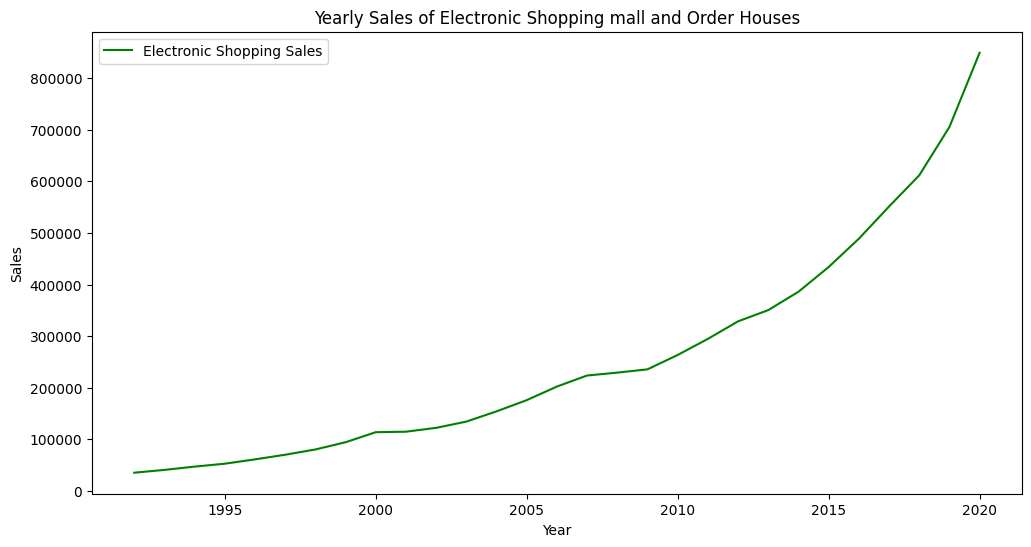

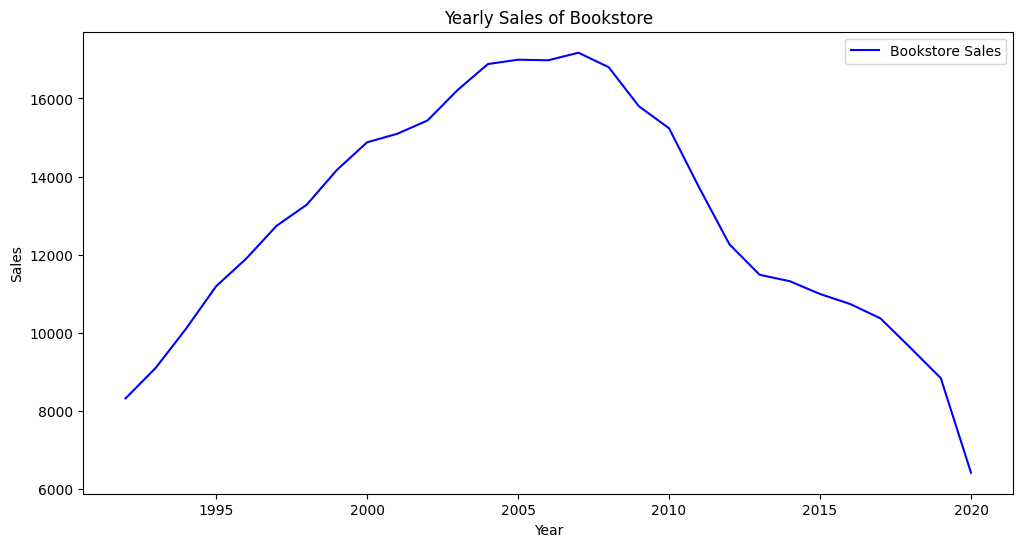

In [ ]:
df.head()

# Display the first few rows of the dataframe
print(df.head())

plt.figure(figsize=(12, 6))
plt.plot(df['sales_year'], df['electronic_shopping_mail_order_houses_sales'], label='Electronic Shopping Sales', color='green')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Yearly Sales of Electronic Shopping mall and Order Houses')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df['sales_year'], df['bookstore_sales'], label='Bookstore Sales', color='blue')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Yearly Sales of Bookstore')
plt.legend()
plt.show()


In [ ]:
df2 = pd.read_csv('C:/sql_data/us_printed_booksales.csv')

df2.head()

,year,sales_in_millions
0,2004,648.0
1,2005,710.0
2,2006,721.0
3,2007,758.0
4,2008,778.0


Text(0, 0.5, 'Sales in million units')

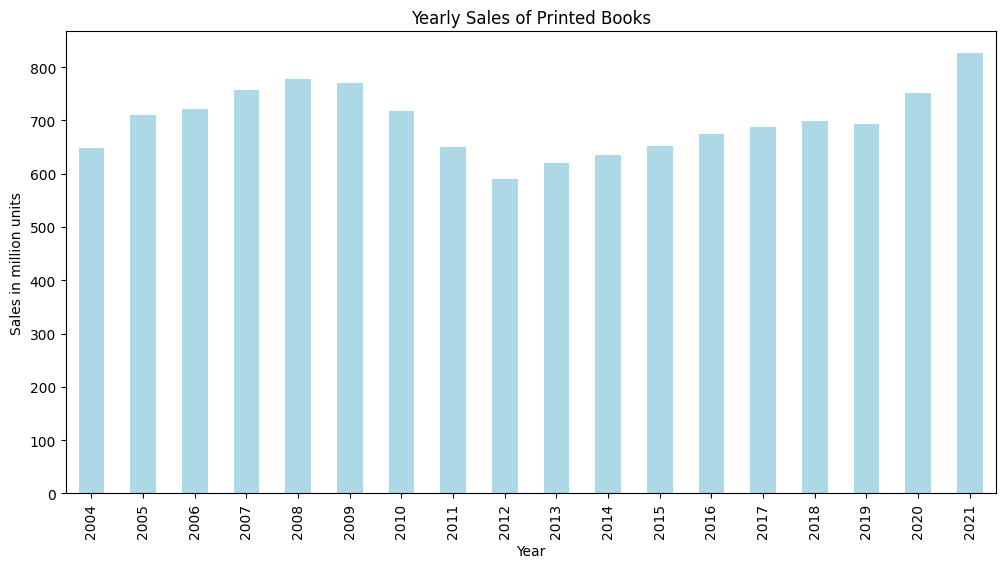

In [ ]:
df2['year'] = pd.to_datetime(df2['year'], format='%Y')
df2['year'] = df2['year'].dt.strftime('%Y')

plt.figure(figsize=(12, 6))
df2.set_index('year')['sales_in_millions'].plot(kind='bar', color='lightblue')
plt.title('Yearly Sales of Printed Books')
plt.xlabel('Year')
plt.ylabel('Sales in million units')

In [ ]:
df3 = pd.read_csv('C:/sql_data/Amazon_net_revenue.csv')

df3.head()

,year,revenue_in_billion_usd
0,2004,6.92
1,2005,8.49
2,2006,10.71
3,2007,14.84
4,2008,19.17


Text(0, 0.5, 'Sales in Billion U.S. Dollars')

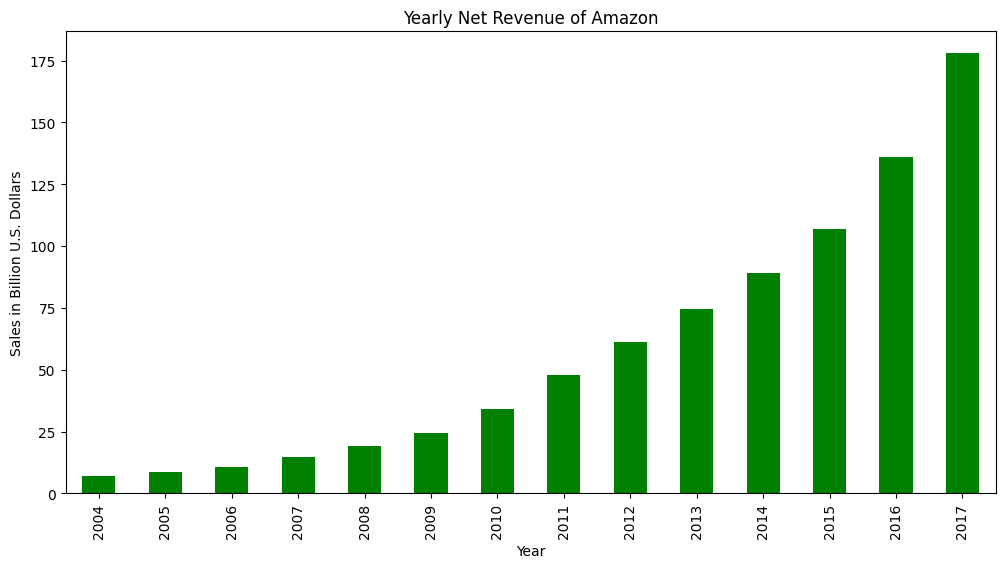

In [ ]:
df3['year'] = pd.to_datetime(df3['year'], format='%Y')
df3['year'] = df3['year'].dt.strftime('%Y')

plt.figure(figsize=(12, 6))
df3.set_index('year')['revenue_in_billion_usd'].plot(kind='bar', color='green')
plt.title('Yearly Net Revenue of Amazon')
plt.xlabel('Year')
plt.ylabel('Sales in Billion U.S. Dollars')

### 3주차 세션 발표 

미국 fuel dealer 매출 데이터  
fuel dealer란 난방을 위해 난방유, 프로판을 사용하는 가정이 많은데 가정에 에너지를 공급하는 소매업체 및 업자를 의미합니다. 

In [3]:
fuel_sales = pd.read_csv("D:/김동영/94_sqldata/us_fuel_sale.csv")

fuel_sales

,sales_month,sales,absolute_diff,pct_diff
0,1992-01-01,1916,NaN,NaN
1,1993-01-01,1893,-23.0,-1.200418
2,1994-01-01,2419,526.0,27.786582
3,1995-01-01,2152,-267.0,-11.037619
4,1996-01-01,2865,713.0,33.131970
...,...,...,...,...
343,2016-12-01,3164,626.0,24.665091
344,2017-12-01,3777,613.0,19.374210
345,2018-12-01,3392,-385.0,-10.193275
346,2019-12-01,3346,-46.0,-1.356132


In [5]:
fuel_sales['sales_month'] = pd.to_datetime(fuel_sales['sales_month'])

In [9]:
fuel_sales.sort_values(by='sales_month', ascending=True, inplace=True)
fuel_sales.head(20)

,sales_month,sales,absolute_diff,pct_diff
0,1992-01-01,1916,NaN,NaN
29,1992-02-01,1627,NaN,NaN
58,1992-03-01,1537,NaN,NaN
87,1992-04-01,1341,NaN,NaN
116,1992-05-01,1163,NaN,NaN
145,1992-06-01,1016,NaN,NaN
174,1992-07-01,969,NaN,NaN
203,1992-08-01,1005,NaN,NaN
232,1992-09-01,1150,NaN,NaN
261,1992-10-01,1431,NaN,NaN


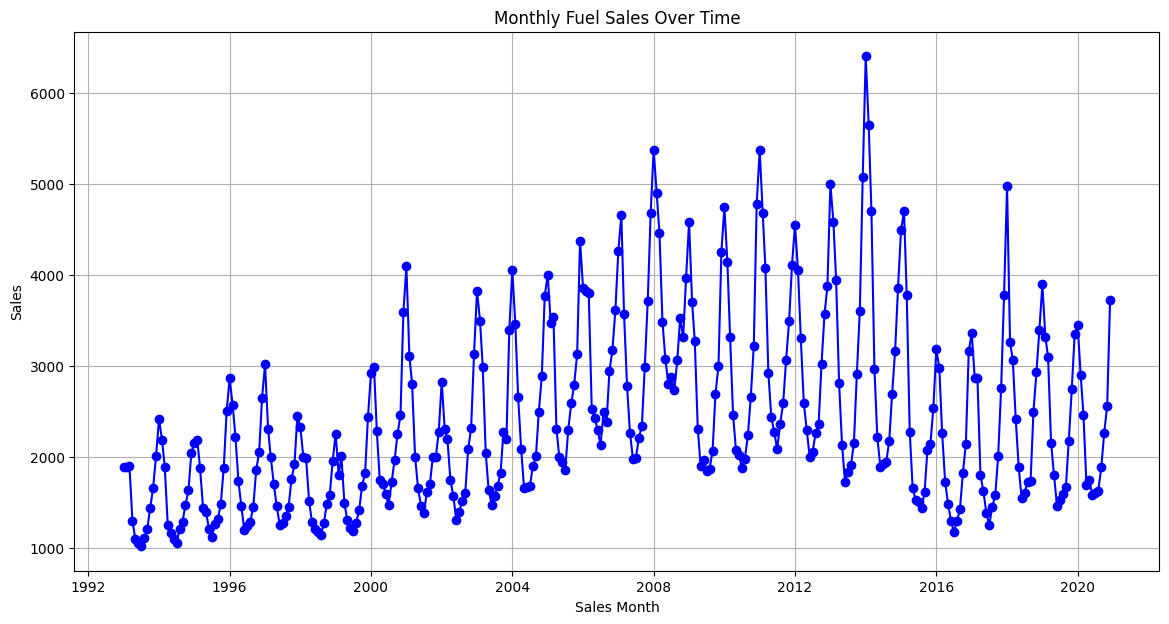

In [12]:
fuel_sales_1993 = fuel_sales[fuel_sales['sales_month'].dt.year >= 1993]

plt.figure(figsize=(14, 7))
plt.plot(fuel_sales_1993['sales_month'], fuel_sales_1993['sales'], marker='o', linestyle='-', color='b')
plt.xlabel('Sales Month')
plt.ylabel('Sales')
plt.title('Monthly Fuel Sales Over Time')
plt.grid(True)
plt.show()



month
1     3726.931034
2     3296.551724
3     2892.172414
4     2090.482759
5     1778.896552
6     1601.862069
7     1575.482759
8     1698.448276
9     1844.137931
10    2269.724138
11    2573.379310
12    3335.103448
Name: sales, dtype: float64
month
1     108081
2      95600
3      83873
4      60624
5      51588
6      46454
7      45689
8      49255
9      53480
10     65822
11     74628
12     96718
Name: sales, dtype: int64


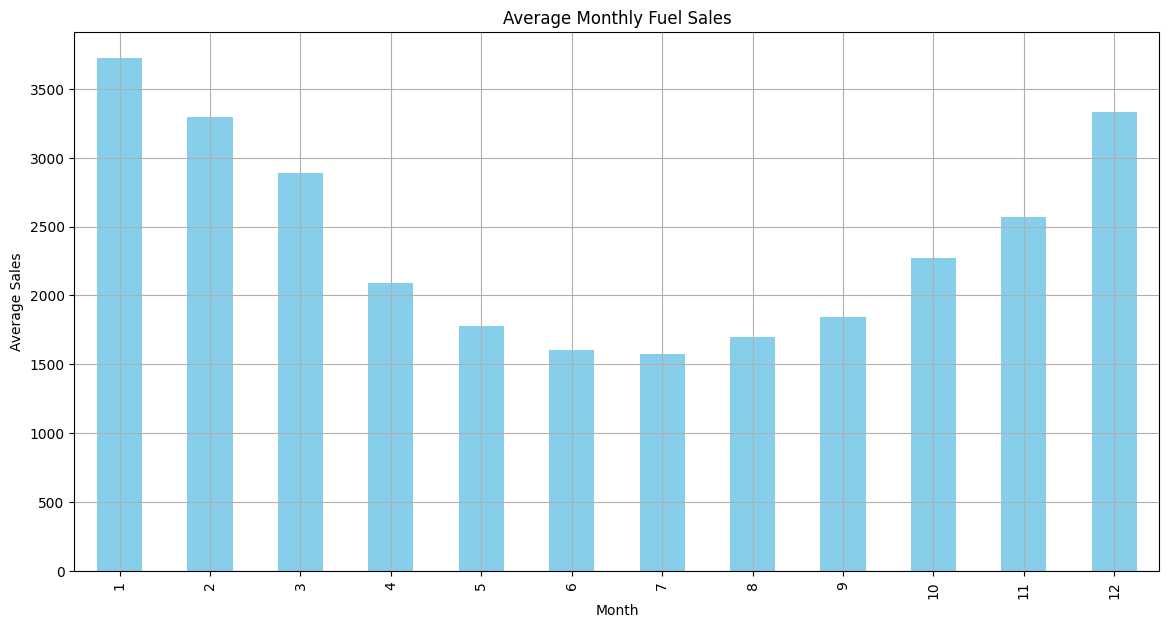

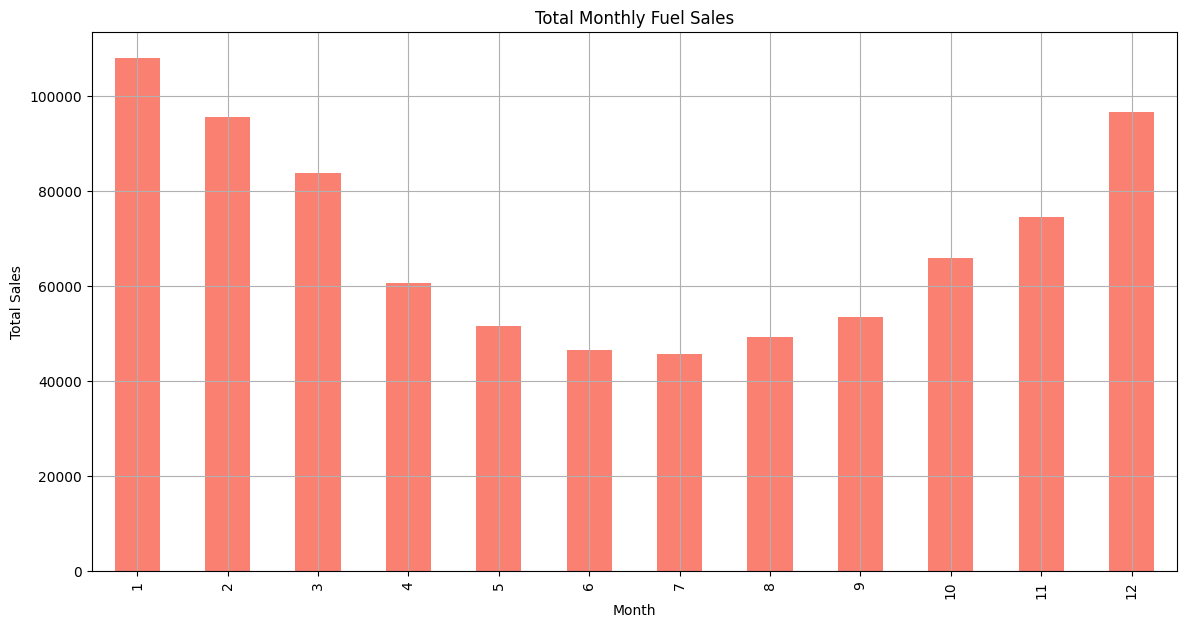

In [19]:
# Extract month from sales_month
fuel_sales['month'] = fuel_sales['sales_month'].dt.month

# Group by month and calculate the mean sales
monthly_avg_sales = fuel_sales.groupby('month')['sales'].mean()

print(monthly_avg_sales)

# Calculate the sum of sales for each month
monthly_sum_sales = fuel_sales.groupby('month')['sales'].sum()

print(monthly_sum_sales)

plt.figure(figsize=(14, 7))
monthly_avg_sales.plot(kind='bar', color='skyblue')
plt.title('Average Monthly Fuel Sales')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 7))
monthly_sum_sales.plot(kind='bar', color='salmon')
plt.title('Total Monthly Fuel Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

월별 평균 fuel retail 매출과 매출합을 확인해본 결과 여름보다는 겨울에 매출이 더 높은 것을 알 수 있었다. 

그 이유는 계절별 에너지 수요 패턴과 밀접한 관련이 있는데 특히 난방 연료 수요가 큰 영향을 관련있습니다.  

월별 fuel retail 매출을 확인한 결과 증가 감소 추세가 나타나는 것을 확인하였다. 

시계열 분석을 위해 전년 대비 동월 fuel retail 매출을 확인해보았다.  

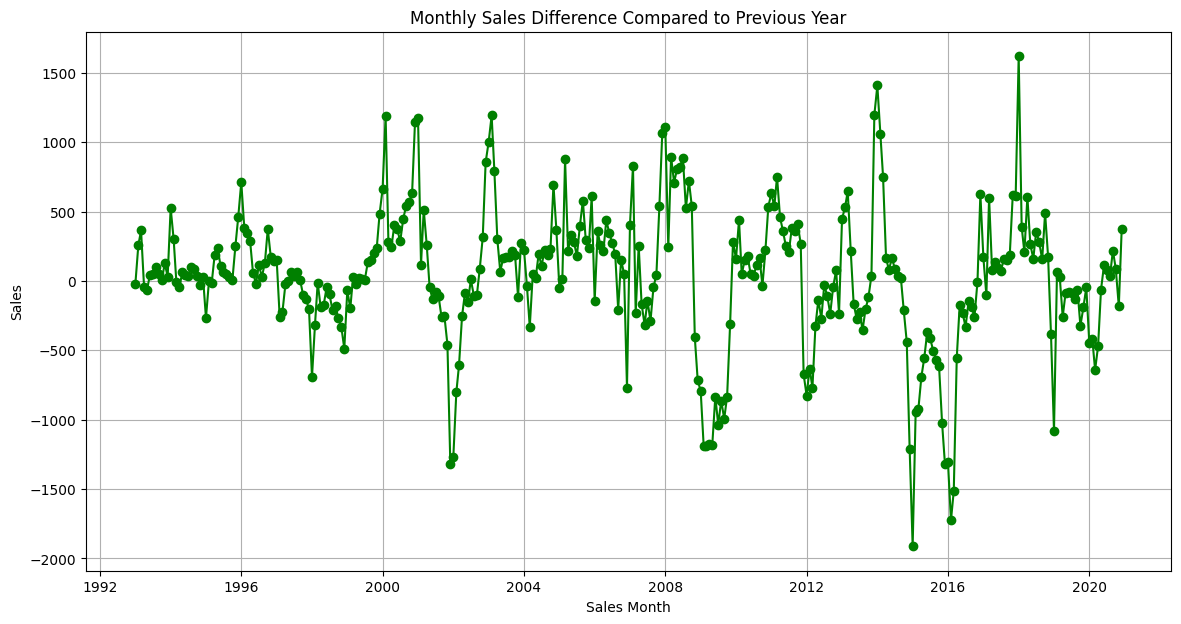

In [16]:
plt.figure(figsize=(14, 7))
plt.plot(fuel_sales_1993['sales_month'], fuel_sales_1993['absolute_diff'], marker='o', linestyle='-', color='g')
plt.xlabel('Sales Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Difference Compared to Previous Year')
plt.grid(True)
plt.show()



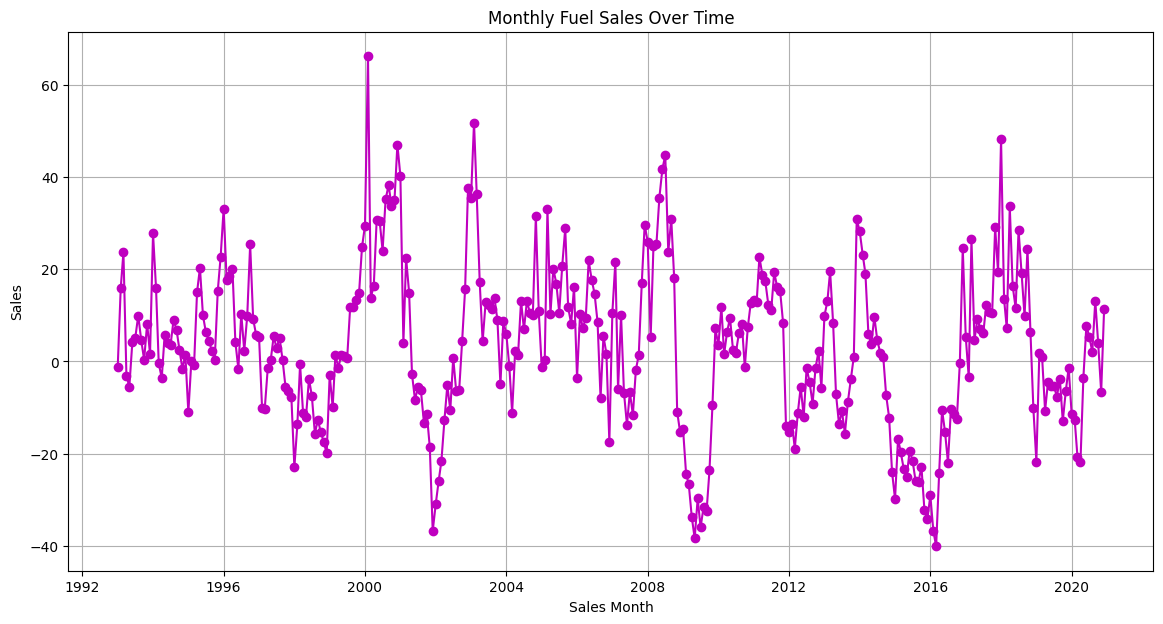

In [24]:
plt.figure(figsize=(14, 7))
plt.plot(fuel_sales_1993['sales_month'], fuel_sales_1993['pct_diff'], marker='o', linestyle='-', color='m')
plt.xlabel('Sales Month')
plt.ylabel('Sales')
plt.title('Monthly Fuel Sales Over Time')
plt.grid(True)
plt.show()



2001년 10~12월, 2008년 말~2009년 초, 2014년 말~2015년 이 세 개의 시기에 fuel_retail 전년 대비 동월 매출이 크게 하락한 것을 확인할 수 있었다. 
이러한 이유는 특정 이벤트에 영향을 받아 일반적이지 않은 값이 저장된 경우가 발생했을 수도 있어서이다.  이렇게 특정 이벤트로 인한 노이즈는 계절성을 파악하는데 있어서 어려움을 발생시킬 수 있다. 따라서 이러한 문제를 해결하고자 노이즈를 제거해야 하고 노이즈 제거 방법으로 현재 값을 이전 구간 값 2개 이상과 비교하는 방법이 있다.  

이를 다중 구간 비교라고 부른다.   

In [45]:
fuel_sales2 = pd.read_csv("D:/김동영/94_sqldata/us_fuel_sale2.csv")

In [46]:
fuel_sales2

fuel_sales2['sales_month'] = pd.to_datetime(fuel_sales['sales_month'])

fuel_sales2.sort_values(by='sales_month', ascending=True, inplace=True)
fuel_sales2

,sales_month,sales,pct_of_3_prev
0,1992-01-01,1916,NaN
29,1992-02-01,1627,NaN
58,1992-03-01,1537,NaN
87,1992-04-01,1341,NaN
116,1992-05-01,1163,NaN
...,...,...,...
231,2020-08-01,1630,102.386935
260,2020-09-01,1885,113.668342
289,2020-10-01,2262,101.526032
318,2020-11-01,2563,91.069525


<Figure size 3000x2000 with 0 Axes>

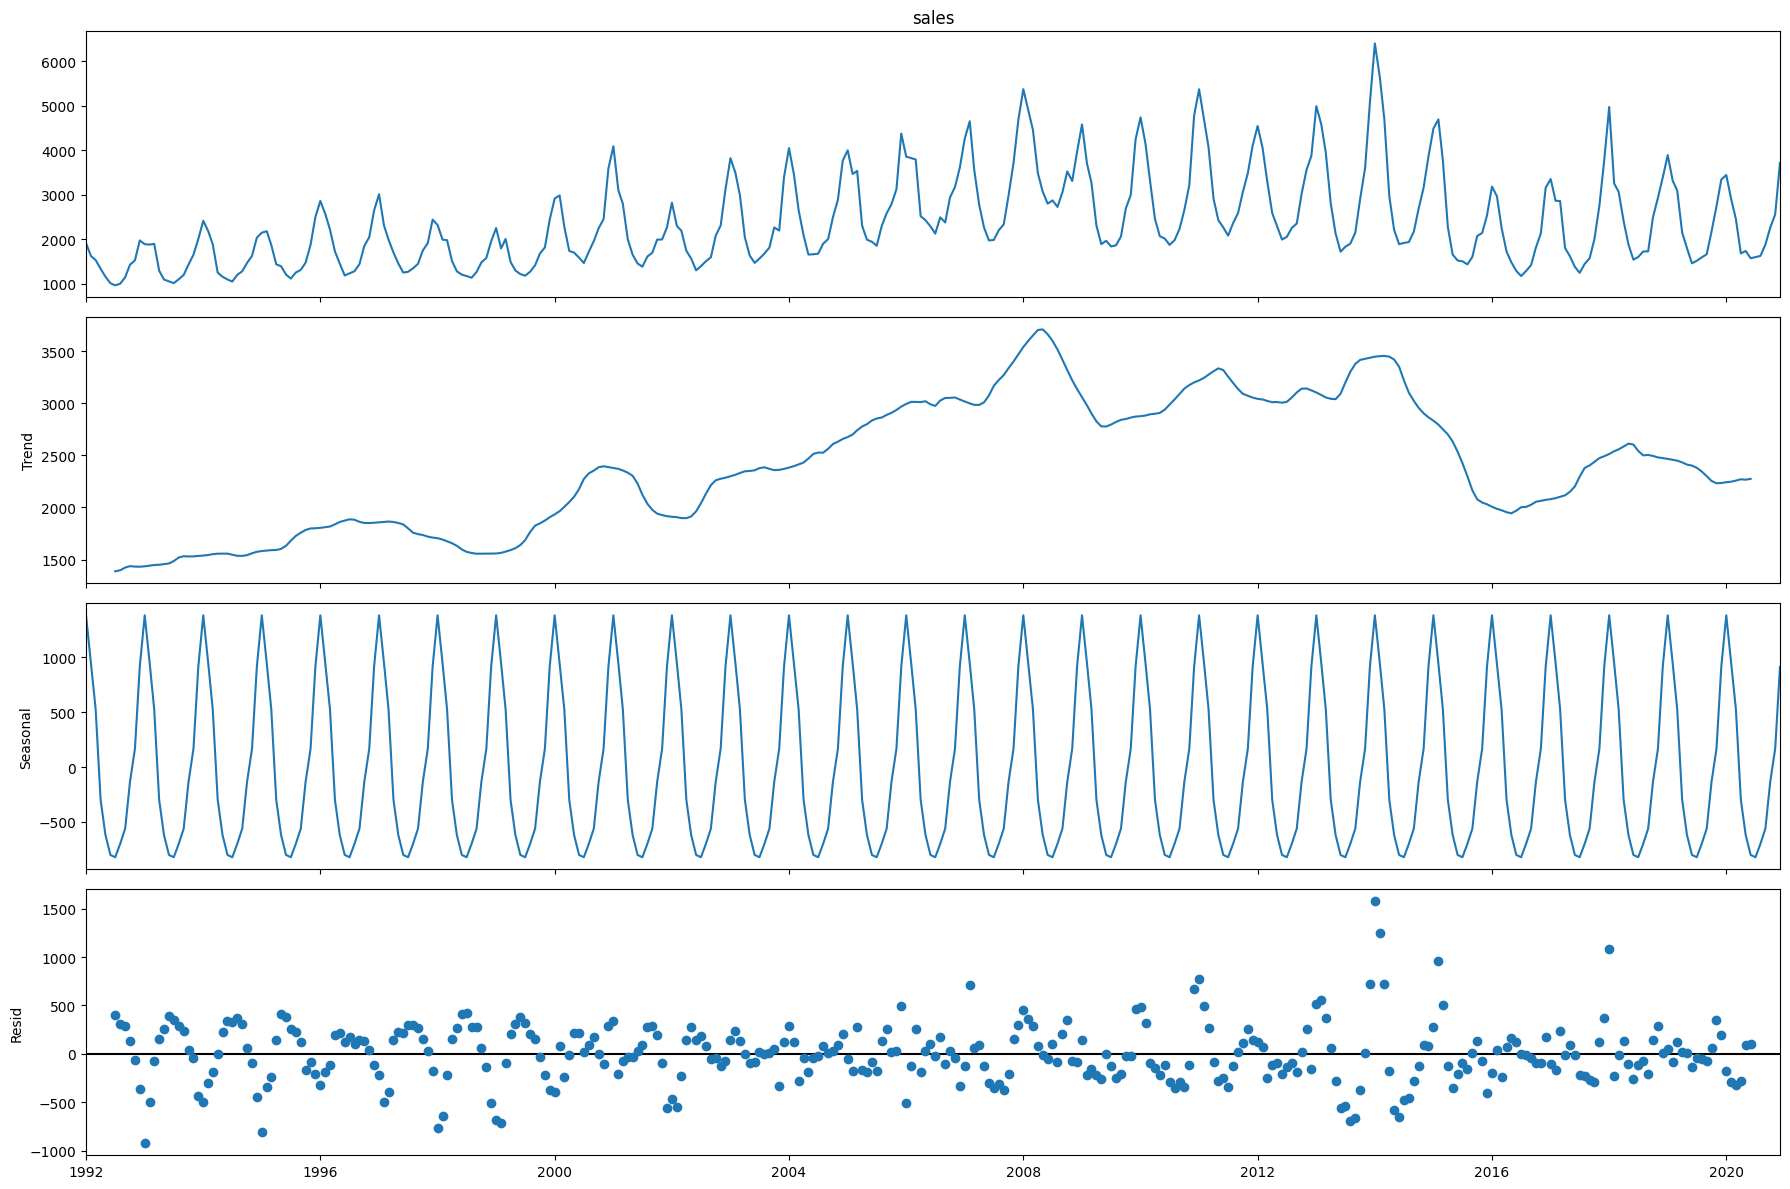

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set the sales_month column as the index
fuel_sales2.set_index('sales_month', inplace=True)

# Perform seasonal decomposition
result = seasonal_decompose(fuel_sales2['sales'], model='additive', period=12)

# Plot the decomposition
plt.figure(figsize=(30, 20))
result.plot()
plt.show()


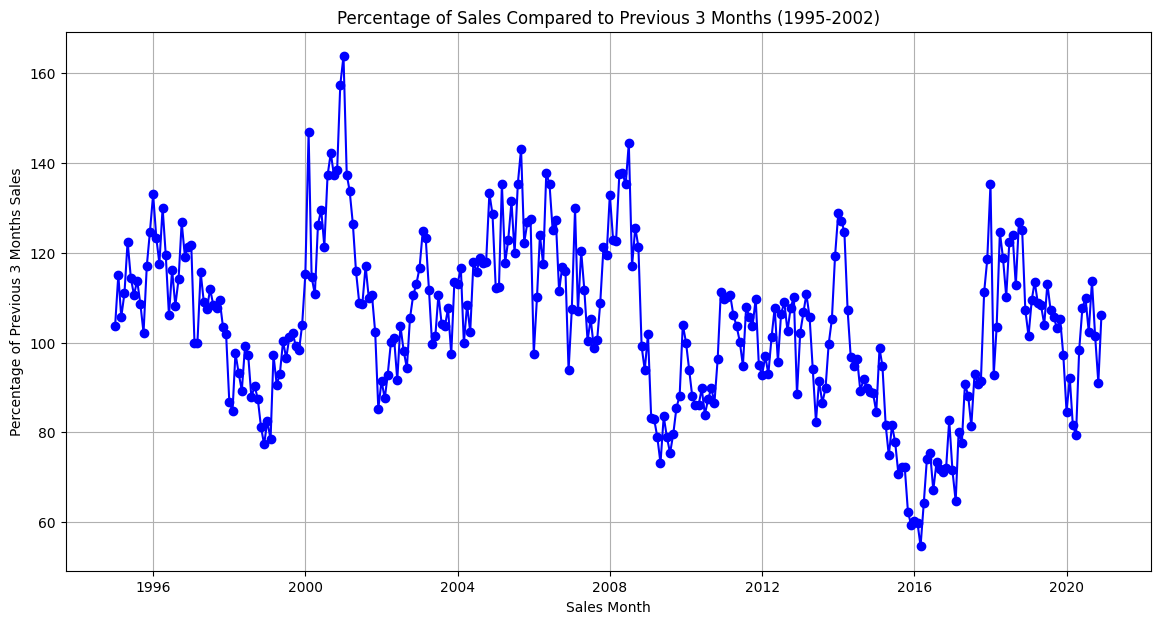

In [40]:
plt.figure(figsize=(14, 7))
plt.plot(fuel_sales2['sales_month'], fuel_sales2['pct_of_3_prev'], marker='o', linestyle='-', color='b')
plt.xlabel('Sales Month')
plt.ylabel('Percentage of Previous 3 Months Sales')
plt.title('Percentage of Sales Compared to Previous 3 Months (1995-2002)')
plt.grid(True)
plt.show()